# Semana 3 — Tiempos de Primera Pasada y Ocupación

Esta sesión introduce dos herramientas para medir **cuánto tarda** una cadena en alcanzar un estado y **cuánto tiempo pasa** en cada estado.

| Herramienta | Definición usada en este laboratorio | Idea de cálculo con NumPy |
|---|---|---|
| **Tiempo de primera pasada al estado objetivo $j$** | $\tau_j=\min\{n\geq 0:X_n=j\}$ y $m_i=E[\tau_j\mid X_0=i]$. Por definición, $m_j=0$. | Análisis de un paso: $m_i=1+\sum_{k\neq j}P_{ik}m_k$, para $i\neq j$, iterado hasta converger. |
| **Tiempo de ocupación en $H$ períodos** | $M_{ij}(H)=E\left[\sum_{n=0}^{H-1}\mathbf{1}(X_n=j)\mid X_0=i\right]$. | Sumar las distribuciones $\pi(0),\pi(1),\ldots,\pi(H-1)$. |

> **Convención importante:** si usamos un horizonte de $H=12$ períodos, sumamos exactamente 12 distribuciones, desde $n=0$ hasta $n=11$. Por eso los tiempos de ocupación suman 12 y los porcentajes suman 100 %.

El estado objetivo de una primera pasada **no necesita ser absorbente**. El cálculo se detiene conceptualmente en la primera llegada; lo que ocurra después no afecta el tiempo de primera pasada.

Dominios: conservación, inventarios y finanzas. En todos los ejercicios calculamos primero con NumPy y usamos `jmarkov` únicamente como verificación.

In [1]:
!pip install jmarkov

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from jmarkov.dtmc import dtmc

### Cómo trabajar con el cuaderno

Ejecute las celdas de arriba hacia abajo. Los bloques se clasifican así:

- 🧠 **Código central:** debe poder explicar la lógica general de cada instrucción.
- 🧩 **Nueva herramienta:** se introduce con una explicación antes de utilizarla.
- 🎨 **Visualización proporcionada:** ejecútela e interprete el resultado; no necesita dominar todavía todos los comandos de Matplotlib.

El código central evita deliberadamente formas compactas como `zip`, `enumerate`, comprensiones de listas y expresiones condicionales en una sola línea.

---
## Ejercicio 1 — Hábitat del águila calva *(básico)*

El equipo de conservación del Parque Nacional Yellowstone monitorea cada temporada el hábitat de un ejemplar del águila calva. El ave se mueve entre tres zonas: **Bosque**, **Pradera** y **Laguna**.

$$
X_n=\text{hábitat en la temporada }n,
\qquad
\mathcal{S}=\{0=\text{Bosque},\;1=\text{Pradera},\;2=\text{Laguna}\}.
$$

La matriz de transición estimada con registros históricos es:

$$
P=\begin{pmatrix}
0.55&0.30&0.15\\
0.20&0.45&0.35\\
0.25&0.20&0.55
\end{pmatrix}.
$$

**a)** Construya la matriz $P$ en Python y verifique, fila por fila, que las probabilidades suman 1.

In [3]:
# 🧠 Código central
estados_aguila = ['Bosque', 'Pradera', 'Laguna']

P_aguila = np.array([
    [0.55, 0.30, 0.15],
    [0.20, 0.45, 0.35],
    [0.25, 0.20, 0.55]
])

for indice_estado in range(len(estados_aguila)):
    suma_fila = P_aguila[indice_estado, :].sum()
    nombre_estado = estados_aguila[indice_estado]
    print('Fila', nombre_estado, '- suma:', round(suma_fila, 4))

Fila Bosque - suma: 1.0
Fila Pradera - suma: 1.0
Fila Laguna - suma: 1.0


**b)** ¿Cuántas temporadas tarda en promedio el águila en llegar a la **Pradera** por primera vez desde el **Bosque**? ¿Y desde la **Laguna**?

Si $m_i$ es el tiempo esperado hasta alcanzar la Pradera partiendo del estado $i$, entonces:

$$
m_i=1+\sum_{k\neq \text{Pradera}}P_{ik}m_k,
\qquad i\neq \text{Pradera},
\qquad m_{\text{Pradera}}=0.
$$

La ecuación es circular, porque los tiempos aparecen a ambos lados. La resolveremos por aproximaciones sucesivas: empezamos con $m^{(0)}=0$ y repetimos la misma actualización hasta que el vector casi no cambie.

La primera iteración produce un valor igual a 1 para cada estado no objetivo. En las siguientes iteraciones se incorporan trayectorias cada vez más largas.

In [4]:
# 🧠 Una iteración, término a término
objetivo_pradera = 1
numero_estados_aguila = len(estados_aguila)

tiempos_anteriores = np.zeros(numero_estados_aguila)
tiempos_nuevos = np.zeros(numero_estados_aguila)

for estado_actual in range(numero_estados_aguila):

    if estado_actual != objetivo_pradera:
        suma = 1.0

        for estado_siguiente in range(numero_estados_aguila):

            if estado_siguiente != objetivo_pradera:
                suma = (
                    suma
                    + P_aguila[estado_actual, estado_siguiente]
                    * tiempos_anteriores[estado_siguiente]
                )

        tiempos_nuevos[estado_actual] = suma

print('Primera iteración:', tiempos_nuevos)

Primera iteración: [1. 0. 1.]


In [5]:
# 🧠 Repetimos la misma actualización hasta converger
maximo_iteraciones = 2000
tolerancia = 0.00000001

tiempos_anteriores = np.zeros(numero_estados_aguila)

for iteracion in range(1, maximo_iteraciones + 1):
    tiempos_nuevos = np.zeros(numero_estados_aguila)

    for estado_actual in range(numero_estados_aguila):

        if estado_actual != objetivo_pradera:
            suma = 1.0

            for estado_siguiente in range(numero_estados_aguila):

                if estado_siguiente != objetivo_pradera:
                    suma = (
                        suma
                        + P_aguila[estado_actual, estado_siguiente]
                        * tiempos_anteriores[estado_siguiente]
                    )

            tiempos_nuevos[estado_actual] = suma

    cambio_maximo = np.max(
        np.abs(tiempos_nuevos - tiempos_anteriores)
    )

    tiempos_anteriores = tiempos_nuevos.copy()

    if cambio_maximo < tolerancia:
        break

m_pradera_manual = tiempos_anteriores.copy()

print('Iteraciones hasta convergencia:', iteracion)
print('Tiempo esperado de primera pasada a Pradera:')

for estado_actual in range(numero_estados_aguila):
    if estado_actual != objetivo_pradera:
        print(
            estados_aguila[estado_actual], '-> Pradera:',
            round(m_pradera_manual[estado_actual], 4),
            'temporadas'
        )

Iteraciones hasta convergencia: 64
Tiempo esperado de primera pasada a Pradera:
Bosque -> Pradera: 3.6364 temporadas
Laguna -> Pradera: 4.2424 temporadas


**c)** El águila se encuentra actualmente en la **Laguna** ($X_0=2$). Calcule el tiempo esperado de ocupación en cada hábitat durante **12 temporadas**.

Como contamos exactamente 12 observaciones, sumamos:

$$
\pi(0)+\pi(1)+\cdots+\pi(11).
$$

In [6]:
# 🧠 Ocupación durante H=12 observaciones
H_aguila = 12

distribucion_laguna = np.array([0.0, 0.0, 1.0])
distribucion_actual = distribucion_laguna.copy()
ocupacion_aguila = distribucion_laguna.copy()

for periodo in range(1, H_aguila):
    distribucion_actual = distribucion_actual @ P_aguila
    ocupacion_aguila = ocupacion_aguila + distribucion_actual

print('Temporadas esperadas en cada hábitat:')

for indice_estado in range(numero_estados_aguila):
    tiempo = ocupacion_aguila[indice_estado]
    porcentaje = tiempo / H_aguila * 100

    print(
        estados_aguila[indice_estado], ':',
        round(tiempo, 4), 'temporadas -',
        round(porcentaje, 1), '%'
    )

print('Suma de tiempos:', round(ocupacion_aguila.sum(), 4))

Temporadas esperadas en cada hábitat:
Bosque : 3.5743 temporadas - 29.8 %
Pradera : 3.2615 temporadas - 27.2 %
Laguna : 5.1642 temporadas - 43.0 %
Suma de tiempos: 12.0


**d)** Calcule con NumPy la distribución estacionaria $\boldsymbol{\pi}$ y compare sus componentes con la fracción esperada de ocupación cuando el horizonte es grande.

En una cadena ergódica:

$$
\frac{M_{ij}(H)}{H}\longrightarrow \pi_j
\qquad \text{cuando }H\longrightarrow\infty.
$$

In [7]:
# 🧠 Distribución estacionaria por iteración
pi_anterior = np.array([1/3, 1/3, 1/3])
tolerancia_estacionaria = 0.00000001

for iteracion_pi in range(1, 1001):
    pi_nueva = pi_anterior @ P_aguila

    cambio_maximo = np.max(
        np.abs(pi_nueva - pi_anterior)
    )

    pi_anterior = pi_nueva.copy()

    if cambio_maximo < tolerancia_estacionaria:
        break

pi_aguila_manual = pi_anterior.copy()

print('Distribución estacionaria:')
for indice_estado in range(numero_estados_aguila):
    print(
        estados_aguila[indice_estado], ':',
        round(pi_aguila_manual[indice_estado], 4)
    )

# Ocupación en un horizonte largo
H_largo = 200
distribucion_actual = distribucion_laguna.copy()
ocupacion_larga = distribucion_laguna.copy()

for periodo in range(1, H_largo):
    distribucion_actual = distribucion_actual @ P_aguila
    ocupacion_larga = ocupacion_larga + distribucion_actual

fraccion_ocupacion = ocupacion_larga / H_largo

print('\nFracción esperada de ocupación con H =', H_largo)
for indice_estado in range(numero_estados_aguila):
    print(
        estados_aguila[indice_estado], ':',
        round(fraccion_ocupacion[indice_estado], 4)
    )

Distribución estacionaria:
Bosque : 0.3349
Pradera : 0.3113
Laguna : 0.3538

Fracción esperada de ocupación con H = 200
Bosque : 0.3327
Pradera : 0.3089
Laguna : 0.3584


### Verificación con `jmarkov`

- **Irreducible:** desde cualquier estado puede alcanzarse eventualmente cualquier otro.
- **Período 1:** la cadena no está obligada a regresar siguiendo un ciclo rígido.
- Una cadena finita irreducible y aperiódica es ergódica.

En `jmarkov`, `occupation_time(n)` suma desde $P^0$ hasta $P^n$. Por eso, para contar $H$ observaciones usamos `occupation_time(H - 1)`.

In [8]:
# Verificación con jmarkov
cadena_aguila = dtmc(P_aguila)

print('Es ergódica:', cadena_aguila.is_ergodic())
print('Período:', cadena_aguila.period())

m_aguila_jmarkov = cadena_aguila.first_passage_time(objetivo_pradera)

print('\nPrimera pasada a Pradera:')
indice_resultado = 0

for estado_actual in range(numero_estados_aguila):
    if estado_actual != objetivo_pradera:
        print(
            estados_aguila[estado_actual],
            '- NumPy:', round(m_pradera_manual[estado_actual], 4),
            '- jmarkov:', round(m_aguila_jmarkov[indice_resultado][0], 4)
        )
        indice_resultado = indice_resultado + 1

ocupacion_aguila_jmarkov = (
    cadena_aguila.occupation_time(H_aguila - 1)[2]
)

print('\nOcupación con NumPy:', np.round(ocupacion_aguila, 4))
print('Ocupación con jmarkov:', np.round(ocupacion_aguila_jmarkov, 4))

pi_aguila_jmarkov = cadena_aguila.steady_state()
print('\nPi con NumPy:', np.round(pi_aguila_manual, 4))
print('Pi con jmarkov:', np.round(pi_aguila_jmarkov, 4))

Es ergódica: True
Período: 1

Primera pasada a Pradera:
Bosque - NumPy: 3.6364 - jmarkov: 3.6364
Laguna - NumPy: 4.2424 - jmarkov: 4.2424

Ocupación con NumPy: [3.5743 3.2615 5.1642]
Ocupación con jmarkov: [3.5743 3.2615 5.1642]

Pi con NumPy: [0.3349 0.3113 0.3538]
Pi con jmarkov: [0.3349 0.3113 0.3538]


---
## Ejercicio 2 — Inventario bajo política $(s,S)$: tiempo hasta *stockout* *(intermedio)*

Una tienda aplica la política $(s=2,S=6)$: si el inventario al inicio del día es 2 o menor, se repone inmediatamente hasta 6 unidades. Después ocurre la demanda diaria $D\sim\text{Poisson}(\lambda=2)$.

$$
X_n=\text{unidades al inicio del día }n,
\qquad
\mathcal{S}=\{0,1,2,3,4,5,6\}.
$$

Si $\widetilde{i}$ es el inventario disponible después de aplicar la política:

$$
\widetilde{i}=\begin{cases}
6,&i\leq2,\\
i,&i>2,
\end{cases}
$$

entonces:

$$
P_{ij}=\begin{cases}
P(D=\widetilde{i}-j),&j\geq1,\\
P(D\geq\widetilde{i}),&j=0.
\end{cases}
$$

**a)** Construya la matriz $P$ de tamaño $7	imes7$ y verifique sus filas.

In [9]:
# 🧠 Construcción explícita de la matriz
lambda_demanda = 2
punto_reorden = 2
nivel_reposicion = 6
capacidad = 6
numero_estados_inventario = capacidad + 1

P_inventario = np.zeros((
    numero_estados_inventario,
    numero_estados_inventario
))

for inventario_actual in range(numero_estados_inventario):

    if inventario_actual <= punto_reorden:
        inventario_disponible = nivel_reposicion
    else:
        inventario_disponible = inventario_actual

    for inventario_siguiente in range(numero_estados_inventario):

        if inventario_siguiente >= 1:
            demanda_necesaria = (
                inventario_disponible
                - inventario_siguiente
            )

            P_inventario[
                inventario_actual,
                inventario_siguiente
            ] = poisson.pmf(
                demanda_necesaria,
                lambda_demanda
            )

        else:
            P_inventario[
                inventario_actual,
                0
            ] = poisson.sf(
                inventario_disponible - 1,
                lambda_demanda
            )

filas_validas = True

for inventario_actual in range(numero_estados_inventario):
    suma_fila = P_inventario[inventario_actual, :].sum()
    print('Fila', inventario_actual, '- suma:', round(suma_fila, 6))

    if not np.isclose(suma_fila, 1.0):
        filas_validas = False

print('\nTodas las filas son válidas:', filas_validas)
print('\nMatriz de transición:')
print(np.round(P_inventario, 3))

Fila 0 - suma: 1.0
Fila 1 - suma: 1.0
Fila 2 - suma: 1.0
Fila 3 - suma: 1.0
Fila 4 - suma: 1.0
Fila 5 - suma: 1.0
Fila 6 - suma: 1.0

Todas las filas son válidas: True

Matriz de transición:
[[0.017 0.036 0.09  0.18  0.271 0.271 0.135]
 [0.017 0.036 0.09  0.18  0.271 0.271 0.135]
 [0.017 0.036 0.09  0.18  0.271 0.271 0.135]
 [0.323 0.271 0.271 0.135 0.    0.    0.   ]
 [0.143 0.18  0.271 0.271 0.135 0.    0.   ]
 [0.053 0.09  0.18  0.271 0.271 0.135 0.   ]
 [0.017 0.036 0.09  0.18  0.271 0.271 0.135]]


**b)** Calcule el tiempo esperado hasta el primer *stockout* desde cada estado:

$$
m_i=1+\sum_{k\neq0}P_{ik}m_k,
\qquad m_0=0.
$$

¿Cuántos días se espera que pasen hasta el primer stockout si hoy hay 6 unidades?

In [10]:
# 🧠 Primera pasada hasta stockout
objetivo_stockout = 0
maximo_iteraciones = 5000
tolerancia = 0.00000001

tiempos_anteriores = np.zeros(numero_estados_inventario)

for iteracion in range(1, maximo_iteraciones + 1):
    tiempos_nuevos = np.zeros(numero_estados_inventario)

    for inventario_actual in range(numero_estados_inventario):

        if inventario_actual != objetivo_stockout:
            suma = 1.0

            for inventario_siguiente in range(numero_estados_inventario):

                if inventario_siguiente != objetivo_stockout:
                    suma = (
                        suma
                        + P_inventario[
                            inventario_actual,
                            inventario_siguiente
                        ]
                        * tiempos_anteriores[inventario_siguiente]
                    )

            tiempos_nuevos[inventario_actual] = suma

    cambio_maximo = np.max(
        np.abs(tiempos_nuevos - tiempos_anteriores)
    )

    tiempos_anteriores = tiempos_nuevos.copy()

    if cambio_maximo < tolerancia:
        break

m_stockout_manual = tiempos_anteriores.copy()

print('Iteraciones hasta convergencia:', iteracion)
print('Tiempo esperado hasta stockout:')

for inventario_actual in range(1, numero_estados_inventario):
    print(
        'Desde', inventario_actual, 'unidades:',
        round(m_stockout_manual[inventario_actual], 2),
        'días'
    )

Iteraciones hasta convergencia: 149
Tiempo esperado hasta stockout:
Desde 1 unidades: 9.29 días
Desde 2 unidades: 9.29 días
Desde 3 unidades: 6.97 días
Desde 4 unidades: 8.18 días
Desde 5 unidades: 8.81 días
Desde 6 unidades: 9.29 días


**c)** Partiendo de $X_0=6$, calcule el tiempo esperado de ocupación durante **30 días**. Sumamos exactamente $\pi(0),\ldots,\pi(29)$.

¿Cuántos días se espera que el inventario esté en stockout? ¿Cuántos días estará en zona de reorden, $X\leq2$?

In [11]:
# 🧠 Ocupación durante H=30 días
H_inventario = 30

distribucion_inicial_6 = np.zeros(numero_estados_inventario)
distribucion_inicial_6[6] = 1.0

distribucion_actual = distribucion_inicial_6.copy()
ocupacion_inventario = distribucion_inicial_6.copy()

for dia in range(1, H_inventario):
    distribucion_actual = distribucion_actual @ P_inventario
    ocupacion_inventario = ocupacion_inventario + distribucion_actual

print('Días esperados en cada nivel:')

for inventario_actual in range(numero_estados_inventario):
    tiempo = ocupacion_inventario[inventario_actual]
    porcentaje = tiempo / H_inventario * 100

    print(
        'Estado', inventario_actual, ':',
        round(tiempo, 3), 'días -',
        round(porcentaje, 1), '%'
    )

dias_zona_reorden = 0.0
for inventario_actual in range(punto_reorden + 1):
    dias_zona_reorden = (
        dias_zona_reorden
        + ocupacion_inventario[inventario_actual]
    )

print('\nDías esperados con stockout:', round(ocupacion_inventario[0], 3))
print('Días esperados en zona de reorden:', round(dias_zona_reorden, 3))
print('Suma de tiempos:', round(ocupacion_inventario.sum(), 4))

Días esperados en cada nivel:
Estado 0 : 3.042 días - 10.1 %
Estado 1 : 3.374 días - 11.2 %
Estado 2 : 4.984 días - 16.6 %
Estado 3 : 5.841 días - 19.5 %
Estado 4 : 5.592 días - 18.6 %
Estado 5 : 4.299 días - 14.3 %
Estado 6 : 2.868 días - 9.6 %

Días esperados con stockout: 3.042
Días esperados en zona de reorden: 11.4
Suma de tiempos: 30.0


**d) Validación Monte Carlo.** Estime $m_{6,0}$ mediante simulación.

Primero simulamos una sola trayectoria. La instrucción

```python
rng.choice(numero_estados, p=P[estado_actual])
```

selecciona el siguiente estado usando como probabilidades la fila de la matriz correspondiente al estado actual.

In [12]:
# 🧠 Una sola trayectoria
rng_inventario = np.random.default_rng(seed=42)

estado_actual = 6
maximo_dias = 2000
llego_a_stockout = False

dias_hasta_stockout = np.nan

for dia in range(1, maximo_dias + 1):
    estado_actual = rng_inventario.choice(
        numero_estados_inventario,
        p=P_inventario[estado_actual]
    )

    if estado_actual == objetivo_stockout:
        dias_hasta_stockout = dia
        llego_a_stockout = True
        break

if llego_a_stockout:
    print('La trayectoria llegó a stockout en el día', dias_hasta_stockout)
else:
    print('La trayectoria no llegó a stockout dentro del límite')

La trayectoria llegó a stockout en el día 9


In [13]:
# 🧠 Repetimos el procedimiento 5000 veces
numero_simulaciones = 5000
rng_inventario = np.random.default_rng(seed=42)

tiempos_simulados = []

for simulacion in range(numero_simulaciones):
    estado_actual = 6
    llego_a_stockout = False

    for dia in range(1, maximo_dias + 1):
        estado_actual = rng_inventario.choice(
            numero_estados_inventario,
            p=P_inventario[estado_actual]
        )

        if estado_actual == objetivo_stockout:
            tiempos_simulados.append(dia)
            llego_a_stockout = True
            break

    if llego_a_stockout == False:
        tiempos_simulados.append(np.nan)

tiempos_validos = []

for tiempo in tiempos_simulados:
    if not np.isnan(tiempo):
        tiempos_validos.append(tiempo)

media_simulada = np.mean(tiempos_validos)
media_teorica = m_stockout_manual[6]
error_relativo = (
    abs(media_simulada - media_teorica)
    / media_teorica
    * 100
)

print('Valor teórico:', round(media_teorica, 2), 'días')
print('Valor simulado:', round(media_simulada, 2), 'días')
print('Trayectorias válidas:', len(tiempos_validos), 'de', numero_simulaciones)
print('Error relativo:', round(error_relativo, 2), '%')

Valor teórico: 9.29 días
Valor simulado: 9.33 días
Trayectorias válidas: 5000 de 5000
Error relativo: 0.44 %


**e)** Compare la política $(s=2,S=6)$ con la política $(s=3,S=6)$. Evalúe ambas políticas mediante el tiempo esperado hasta stockout desde $X_0=6$.

> Estamos **evaluando dos políticas dadas**. Todavía no estamos buscando automáticamente la política óptima.

In [14]:
# 🧠 Matriz de la política alternativa
punto_reorden_alternativo = 3

P_inventario_alternativa = np.zeros((
    numero_estados_inventario,
    numero_estados_inventario
))

for inventario_actual in range(numero_estados_inventario):

    if inventario_actual <= punto_reorden_alternativo:
        inventario_disponible = nivel_reposicion
    else:
        inventario_disponible = inventario_actual

    for inventario_siguiente in range(numero_estados_inventario):

        if inventario_siguiente >= 1:
            demanda_necesaria = (
                inventario_disponible
                - inventario_siguiente
            )

            P_inventario_alternativa[
                inventario_actual,
                inventario_siguiente
            ] = poisson.pmf(
                demanda_necesaria,
                lambda_demanda
            )

        else:
            P_inventario_alternativa[
                inventario_actual,
                0
            ] = poisson.sf(
                inventario_disponible - 1,
                lambda_demanda
            )

# Primera pasada para la política alternativa
tiempos_anteriores = np.zeros(numero_estados_inventario)

for iteracion in range(1, maximo_iteraciones + 1):
    tiempos_nuevos = np.zeros(numero_estados_inventario)

    for inventario_actual in range(numero_estados_inventario):

        if inventario_actual != objetivo_stockout:
            suma = 1.0

            for inventario_siguiente in range(numero_estados_inventario):

                if inventario_siguiente != objetivo_stockout:
                    suma = (
                        suma
                        + P_inventario_alternativa[
                            inventario_actual,
                            inventario_siguiente
                        ]
                        * tiempos_anteriores[inventario_siguiente]
                    )

            tiempos_nuevos[inventario_actual] = suma

    cambio_maximo = np.max(
        np.abs(tiempos_nuevos - tiempos_anteriores)
    )

    tiempos_anteriores = tiempos_nuevos.copy()

    if cambio_maximo < tolerancia:
        break

m_stockout_alternativa = tiempos_anteriores.copy()

print('Política (s=2, S=6):', round(m_stockout_manual[6], 2), 'días')
print('Política (s=3, S=6):', round(m_stockout_alternativa[6], 2), 'días')
print(
    'Diferencia:',
    round(m_stockout_alternativa[6] - m_stockout_manual[6], 2),
    'días'
)

Política (s=2, S=6): 9.29 días
Política (s=3, S=6): 18.79 días
Diferencia: 9.5 días


### Verificación con `jmarkov`

In [15]:
# Verificación de las dos políticas
cadena_inventario = dtmc(P_inventario)
cadena_inventario_alternativa = dtmc(P_inventario_alternativa)

m_inventario_jmarkov = cadena_inventario.first_passage_time(0)
m_alternativa_jmarkov = (
    cadena_inventario_alternativa.first_passage_time(0)
)

print('Primera pasada con (s=2, S=6):')
for inventario_actual in range(1, numero_estados_inventario):
    indice_jmarkov = inventario_actual - 1

    print(
        'Estado', inventario_actual,
        '- NumPy:', round(m_stockout_manual[inventario_actual], 2),
        '- jmarkov:', round(m_inventario_jmarkov[indice_jmarkov][0], 2)
    )

print('\nDesde X0=6 con política alternativa:')
print('NumPy:', round(m_stockout_alternativa[6], 2))
print('jmarkov:', round(m_alternativa_jmarkov[5][0], 2))

ocupacion_inventario_jmarkov = (
    cadena_inventario.occupation_time(H_inventario - 1)[6]
)

print('\nOcupación con NumPy:', np.round(ocupacion_inventario, 3))
print('Ocupación con jmarkov:', np.round(ocupacion_inventario_jmarkov, 3))

Primera pasada con (s=2, S=6):
Estado 1 - NumPy: 9.29 - jmarkov: 9.29
Estado 2 - NumPy: 9.29 - jmarkov: 9.29
Estado 3 - NumPy: 6.97 - jmarkov: 6.97
Estado 4 - NumPy: 8.18 - jmarkov: 8.18
Estado 5 - NumPy: 8.81 - jmarkov: 8.81
Estado 6 - NumPy: 9.29 - jmarkov: 9.29

Desde X0=6 con política alternativa:
NumPy: 18.79
jmarkov: 18.79

Ocupación con NumPy: [3.042 3.374 4.984 5.841 5.592 4.299 2.868]
Ocupación con jmarkov: [3.042 3.374 4.984 5.841 5.592 4.299 2.868]


---
## Ejercicio 3 — Fondo de inversión: tiempo hasta ruina *(profundización guiada)*

Un fondo de capital privado monitorea su nivel de capital cada mes. El capital se mide en unidades de **USD 1 millón** y puede tomar valores entre 0 y 8. Cuando llega a 0, el fondo entra en estado de ruina y solicita una inyección de capital.

$$
X_n=\text{nivel de capital al final del mes }n,
\qquad
\mathcal{S}=\{0,1,\ldots,8\}.
$$

Las probabilidades son:

$$
P_{i\to j}=\begin{cases}
0.70,&j=1,\;i=0,\\
0.30,&j=0,\;i=0,\\
0.45,&j=i+1,\;1\leq i\leq7,\\
0.20,&j=i,\;1\leq i\leq7,\\
0.35,&j=i-1,\;1\leq i\leq7,\\
0.55,&j=7,\;i=8,\\
0.45,&j=8,\;i=8,\\
0,&\text{en otro caso.}
\end{cases}
$$

**a)** Construya la matriz $P$ de tamaño $9	imes9$ y verifique sus filas.

In [16]:
# 🧠 Construcción de la matriz del fondo
numero_estados_fondo = 9
P_fondo = np.zeros((numero_estados_fondo, numero_estados_fondo))

# Estado 0: inyección de capital o permanencia en ruina
P_fondo[0, 0] = 0.30
P_fondo[0, 1] = 0.70

# Estados interiores 1,...,7
for capital_actual in range(1, 8):
    P_fondo[capital_actual, capital_actual - 1] = 0.35
    P_fondo[capital_actual, capital_actual] = 0.20
    P_fondo[capital_actual, capital_actual + 1] = 0.45

# Estado superior 8
P_fondo[8, 7] = 0.55
P_fondo[8, 8] = 0.45

filas_validas = True

for capital_actual in range(numero_estados_fondo):
    suma_fila = P_fondo[capital_actual, :].sum()
    print('Fila', capital_actual, '- suma:', round(suma_fila, 6))

    if not np.isclose(suma_fila, 1.0):
        filas_validas = False

print('\nTodas las filas son válidas:', filas_validas)

Fila 0 - suma: 1.0
Fila 1 - suma: 1.0
Fila 2 - suma: 1.0
Fila 3 - suma: 1.0
Fila 4 - suma: 1.0
Fila 5 - suma: 1.0
Fila 6 - suma: 1.0
Fila 7 - suma: 1.0
Fila 8 - suma: 1.0

Todas las filas son válidas: True


**b)** Calcule el tiempo esperado hasta ruina desde cada nivel de capital. ¿Cuántos meses tarda, en promedio, un fondo que comienza en el nivel 5?

In [17]:
# 🧠 Tiempo de primera pasada hasta ruina
objetivo_ruina = 0
maximo_iteraciones_fondo = 20000
tolerancia_fondo = 0.000001

tiempos_anteriores = np.zeros(numero_estados_fondo)

for iteracion in range(1, maximo_iteraciones_fondo + 1):
    tiempos_nuevos = np.zeros(numero_estados_fondo)

    for capital_actual in range(numero_estados_fondo):

        if capital_actual != objetivo_ruina:
            suma = 1.0

            for capital_siguiente in range(numero_estados_fondo):

                if capital_siguiente != objetivo_ruina:
                    suma = (
                        suma
                        + P_fondo[capital_actual, capital_siguiente]
                        * tiempos_anteriores[capital_siguiente]
                    )

            tiempos_nuevos[capital_actual] = suma

    cambio_maximo = np.max(
        np.abs(tiempos_nuevos - tiempos_anteriores)
    )

    tiempos_anteriores = tiempos_nuevos.copy()

    if cambio_maximo < tolerancia_fondo:
        break

m_ruina_manual = tiempos_anteriores.copy()

print('Iteraciones hasta convergencia:', iteracion)
print('Tiempo esperado hasta ruina:')

for capital_actual in range(1, numero_estados_fondo):
    print(
        'Capital', capital_actual, ':',
        round(m_ruina_manual[capital_actual], 2),
        'meses'
    )

print(
    '\nDesde capital 5:',
    round(m_ruina_manual[5], 2), 'meses, equivalentes a',
    round(m_ruina_manual[5] / 12, 1), 'años'
)

Iteraciones hasta convergencia: 2380
Tiempo esperado hasta ruina:
Capital 1 : 58.64 meses
Capital 2 : 102.02 meses
Capital 3 : 133.54 meses
Capital 4 : 155.84 meses
Capital 5 : 170.96 meses
Capital 6 : 180.49 meses
Capital 7 : 185.69 meses
Capital 8 : 187.51 meses

Desde capital 5: 170.96 meses, equivalentes a 14.2 años


**c)** Partiendo de $X_0=5$, calcule el tiempo de ocupación durante **60 meses**, es decir, sumando $\pi(0),\ldots,\pi(59)$. ¿Cuántos meses se espera que el fondo permanezca en ruina? ¿Cuántos meses estará en la zona alta, $X\geq6$?

In [18]:
# 🧠 Ocupación durante H=60 meses
H_fondo = 60

distribucion_inicial_5 = np.zeros(numero_estados_fondo)
distribucion_inicial_5[5] = 1.0

distribucion_actual = distribucion_inicial_5.copy()
ocupacion_fondo = distribucion_inicial_5.copy()

for mes in range(1, H_fondo):
    distribucion_actual = distribucion_actual @ P_fondo
    ocupacion_fondo = ocupacion_fondo + distribucion_actual

print('Meses esperados en cada nivel de capital:')

for capital_actual in range(numero_estados_fondo):
    tiempo = ocupacion_fondo[capital_actual]
    porcentaje = tiempo / H_fondo * 100

    print(
        'Capital', capital_actual, ':',
        round(tiempo, 3), 'meses -',
        round(porcentaje, 1), '%'
    )

meses_zona_alta = 0.0
for capital_actual in range(6, numero_estados_fondo):
    meses_zona_alta = meses_zona_alta + ocupacion_fondo[capital_actual]

print('\nMeses esperados en ruina:', round(ocupacion_fondo[0], 3))
print('Meses esperados en zona alta:', round(meses_zona_alta, 3))
print('Suma de tiempos:', round(ocupacion_fondo.sum(), 4))

Meses esperados en cada nivel de capital:
Capital 0 : 1.18 meses - 2.0 %
Capital 1 : 2.429 meses - 4.0 %
Capital 2 : 3.326 meses - 5.5 %
Capital 3 : 4.653 meses - 7.8 %
Capital 4 : 6.584 meses - 11.0 %
Capital 5 : 9.356 meses - 15.6 %
Capital 6 : 10.434 meses - 17.4 %
Capital 7 : 12.297 meses - 20.5 %
Capital 8 : 9.741 meses - 16.2 %

Meses esperados en ruina: 1.18
Meses esperados en zona alta: 32.472
Suma de tiempos: 60.0


**d) Validación Monte Carlo.** En el ejercicio anterior escribimos la simulación completa. Ahora encapsulamos el mismo procedimiento en una función, porque lo reutilizaremos con distintas matrices.

La función sigue siendo un algoritmo sencillo:

1. recibe el estado inicial;
2. simula un período usando una fila de $P$;
3. se detiene cuando alcanza el objetivo;
4. devuelve el número de períodos transcurridos.

In [19]:
# 🧩 Función reutilizable para una trayectoria
def simular_primera_pasada(
    P,
    estado_inicial,
    estado_objetivo,
    maximo_periodos,
    generador
):
    numero_estados = len(P)
    estado_actual = estado_inicial

    for periodo in range(1, maximo_periodos + 1):
        estado_actual = generador.choice(
            numero_estados,
            p=P[estado_actual]
        )

        if estado_actual == estado_objetivo:
            return periodo

    return np.nan

In [20]:
# 🧠 Repetimos la función con un ciclo ordinario
numero_simulaciones_fondo = 5000
maximo_meses = 5000
rng_fondo = np.random.default_rng(seed=7)

tiempos_ruina_simulados = []

for simulacion in range(numero_simulaciones_fondo):
    tiempo = simular_primera_pasada(
        P_fondo,
        estado_inicial=5,
        estado_objetivo=0,
        maximo_periodos=maximo_meses,
        generador=rng_fondo
    )

    tiempos_ruina_simulados.append(tiempo)

tiempos_ruina_validos = []

for tiempo in tiempos_ruina_simulados:
    if not np.isnan(tiempo):
        tiempos_ruina_validos.append(tiempo)

media_ruina_simulada = np.mean(tiempos_ruina_validos)
media_ruina_teorica = m_ruina_manual[5]
error_relativo_ruina = (
    abs(media_ruina_simulada - media_ruina_teorica)
    / media_ruina_teorica
    * 100
)

print('Valor teórico:', round(media_ruina_teorica, 2), 'meses')
print('Valor simulado:', round(media_ruina_simulada, 2), 'meses')
print(
    'Trayectorias válidas:',
    len(tiempos_ruina_validos),
    'de', numero_simulaciones_fondo
)
print('Error relativo:', round(error_relativo_ruina, 2), '%')

Valor teórico: 170.96 meses
Valor simulado: 169.57 meses
Trayectorias válidas: 5000 de 5000
Error relativo: 0.81 %


### 🎨 Visualización proporcionada

La siguiente celda no hace parte de los contenidos de programación evaluados. No es necesario comprender todos los comandos de Matplotlib. Concéntrese en interpretar:

- la dispersión de los tiempos simulados;
- la diferencia entre una trayectoria particular y el valor esperado;
- la cercanía entre la media simulada y la media teórica.

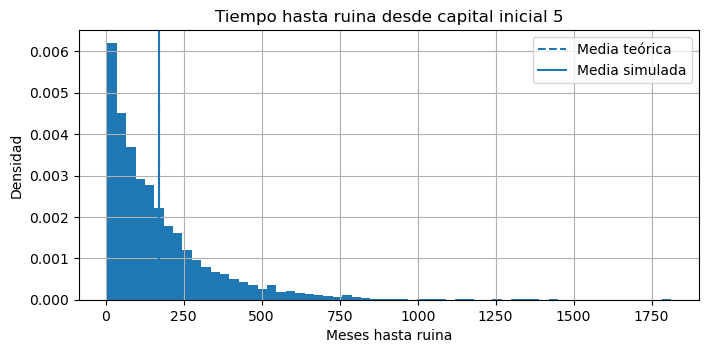

In [21]:
# 🎨 Visualización proporcionada
plt.figure(figsize=(8, 3.5))
plt.hist(tiempos_ruina_validos, bins=60, density=True)
plt.axvline(
    media_ruina_teorica,
    linestyle='--',
    label='Media teórica'
)
plt.axvline(
    media_ruina_simulada,
    linestyle='-',
    label='Media simulada'
)
plt.xlabel('Meses hasta ruina')
plt.ylabel('Densidad')
plt.title('Tiempo hasta ruina desde capital inicial 5')
plt.legend()
plt.grid()
plt.show()

**e)** El fondo modifica su estrategia: la probabilidad de ganancia aumenta de $0.45$ a $0.52$ y la probabilidad de pérdida disminuye de $0.35$ a $0.28$. Reconstruya la cadena y compare los tiempos esperados hasta ruina.

La nueva cadena se mueve con menor frecuencia hacia la ruina. Por eso la iteración puede necesitar más pasos para converger.

> De nuevo, estamos evaluando dos estrategias definidas; no estamos resolviendo todavía un problema de optimización de políticas.

In [22]:
# 🧠 Nueva estrategia de inversión
probabilidad_ganancia_nueva = 0.52
probabilidad_perdida_nueva = 0.28
probabilidad_sin_cambio_nueva = (
    1
    - probabilidad_ganancia_nueva
    - probabilidad_perdida_nueva
)

P_fondo_nuevo = P_fondo.copy()

for capital_actual in range(1, 8):
    P_fondo_nuevo[capital_actual, capital_actual - 1] = (
        probabilidad_perdida_nueva
    )
    P_fondo_nuevo[capital_actual, capital_actual] = (
        probabilidad_sin_cambio_nueva
    )
    P_fondo_nuevo[capital_actual, capital_actual + 1] = (
        probabilidad_ganancia_nueva
    )

# Primera pasada con la nueva estrategia
tiempos_anteriores = np.zeros(numero_estados_fondo)
maximo_iteraciones_nuevo = 200000
tolerancia_nueva = 0.000001

for iteracion in range(1, maximo_iteraciones_nuevo + 1):
    tiempos_nuevos = np.zeros(numero_estados_fondo)

    for capital_actual in range(numero_estados_fondo):

        if capital_actual != objetivo_ruina:
            suma = 1.0

            for capital_siguiente in range(numero_estados_fondo):

                if capital_siguiente != objetivo_ruina:
                    suma = (
                        suma
                        + P_fondo_nuevo[
                            capital_actual,
                            capital_siguiente
                        ]
                        * tiempos_anteriores[capital_siguiente]
                    )

            tiempos_nuevos[capital_actual] = suma

    cambio_maximo = np.max(
        np.abs(tiempos_nuevos - tiempos_anteriores)
    )

    tiempos_anteriores = tiempos_nuevos.copy()

    if cambio_maximo < tolerancia_nueva:
        break

m_ruina_nuevo_manual = tiempos_anteriores.copy()

print('Iteraciones hasta convergencia:', iteracion)
print('Comparación de tiempos hasta ruina:')

for capital_actual in range(1, numero_estados_fondo):
    tiempo_original = m_ruina_manual[capital_actual]
    tiempo_nuevo = m_ruina_nuevo_manual[capital_actual]
    diferencia = tiempo_nuevo - tiempo_original

    print(
        'Capital', capital_actual,
        '- original:', round(tiempo_original, 1),
        '- nueva:', round(tiempo_nuevo, 1),
        '- diferencia:', round(diferencia, 1)
    )

Iteraciones hasta convergencia: 12894
Comparación de tiempos hasta ruina:
Capital 1 - original: 58.6 - nueva: 451.8 - diferencia: 393.2
Capital 2 - original: 102.0 - nueva: 693.2 - diferencia: 591.2
Capital 3 - original: 133.5 - nueva: 821.3 - diferencia: 687.7
Capital 4 - original: 155.8 - nueva: 888.3 - diferencia: 732.4
Capital 5 - original: 171.0 - nueva: 922.5 - diferencia: 751.5
Capital 6 - original: 180.5 - nueva: 938.9 - diferencia: 758.4
Capital 7 - original: 185.7 - nueva: 945.9 - diferencia: 760.2
Capital 8 - original: 187.5 - nueva: 947.7 - diferencia: 760.2


### Verificación con `jmarkov`

In [23]:
# Verificación de las dos estrategias
cadena_fondo = dtmc(P_fondo)
cadena_fondo_nuevo = dtmc(P_fondo_nuevo)

print('Cadena original ergódica:', cadena_fondo.is_ergodic())
print('Cadena nueva ergódica:', cadena_fondo_nuevo.is_ergodic())

m_fondo_jmarkov = cadena_fondo.first_passage_time(0)
m_fondo_nuevo_jmarkov = cadena_fondo_nuevo.first_passage_time(0)

print('\nEstrategia original:')
for capital_actual in range(1, numero_estados_fondo):
    indice_jmarkov = capital_actual - 1

    print(
        'Capital', capital_actual,
        '- NumPy:', round(m_ruina_manual[capital_actual], 2),
        '- jmarkov:', round(m_fondo_jmarkov[indice_jmarkov][0], 2)
    )

print('\nEstrategia nueva:')
for capital_actual in range(1, numero_estados_fondo):
    indice_jmarkov = capital_actual - 1

    print(
        'Capital', capital_actual,
        '- NumPy:', round(m_ruina_nuevo_manual[capital_actual], 1),
        '- jmarkov:', round(m_fondo_nuevo_jmarkov[indice_jmarkov][0], 1)
    )

Cadena original ergódica: True
Cadena nueva ergódica: True

Estrategia original:
Capital 1 - NumPy: 58.64 - jmarkov: 58.64
Capital 2 - NumPy: 102.02 - jmarkov: 102.02
Capital 3 - NumPy: 133.54 - jmarkov: 133.54
Capital 4 - NumPy: 155.84 - jmarkov: 155.84
Capital 5 - NumPy: 170.96 - jmarkov: 170.96
Capital 6 - NumPy: 180.49 - jmarkov: 180.49
Capital 7 - NumPy: 185.69 - jmarkov: 185.69
Capital 8 - NumPy: 187.51 - jmarkov: 187.51

Estrategia nueva:
Capital 1 - NumPy: 451.8 - jmarkov: 451.8
Capital 2 - NumPy: 693.2 - jmarkov: 693.2
Capital 3 - NumPy: 821.3 - jmarkov: 821.3
Capital 4 - NumPy: 888.3 - jmarkov: 888.3
Capital 5 - NumPy: 922.5 - jmarkov: 922.5
Capital 6 - NumPy: 938.9 - jmarkov: 938.9
Capital 7 - NumPy: 945.9 - jmarkov: 945.9
Capital 8 - NumPy: 947.7 - jmarkov: 947.7


---
## Ejercicio abierto — Gestión de inventario de medicamentos críticos

Un hospital gestiona un medicamento crítico con capacidad máxima de 10 unidades. La demanda diaria sigue una distribución Poisson con tasa $\lambda=2$. La política es $(s=3,S=10)$: si el inventario al inicio del día es 3 o menor, se repone hasta 10 antes de atender la demanda.

$$
X_n=\text{unidades al inicio del día }n,
\qquad
\mathcal{S}=\{0,1,\ldots,10\}.
$$

### Checkpoints

1. **Modelo:** derive las reglas y construya $P$.
2. **Primera pasada:** calcule el tiempo esperado hasta stockout desde cada estado.
3. **Ocupación:** durante $H=60$ días, sume $\pi(0),\ldots,\pi(59)$ y calcule los días esperados en zona crítica, $X\leq3$.
4. **Monte Carlo:** valide $m_{10,0}$ con 3000 trayectorias.
5. **Verificación:** compare con `jmarkov` usando `occupation_time(59)`.

Antes de aceptar código generado por una IA, compruebe al menos una transición y una iteración que dependan realmente de la matriz.

### Cómo usar una IA para resolver el ejercicio

**Paso 1.** Escriba primero las reglas de transición.

**Paso 2.** Ejecute la celda de referencia y conserve sus valores.

**Paso 3.** Pida a la IA código legible, sin `zip`, `enumerate`, comprensiones de listas ni expresiones condicionales en una sola línea.

**Paso 4.** Compare la respuesta con las referencias antes de ejecutar las 3000 simulaciones.

**Prompt sugerido:**

```text
Estoy modelando el inventario de un medicamento como una CMTD:

X_n = unidades al inicio del día n
S = {0,1,...,10}
P[i,j] = P(X_(n+1)=j | X_n=i)

Política (s=3,S=10): si i <= 3, se repone hasta 10 antes de atender la demanda.
Demanda D ~ Poisson(lambda=2), sin backorder.

Reglas:
- inventario_disponible = 10 si i <= 3; en otro caso, inventario_disponible = i.
- P[i,j] = P(D = inventario_disponible-j) para j >= 1.
- P[i,0] = P(D >= inventario_disponible).

Ayúdame en este orden:
1. Construir P con NumPy y scipy.stats.poisson y verificar cada fila.
2. Calcular el tiempo hasta stockout mediante la iteración
   m_i = 1 + suma_{k != 0} P[i,k] m_k, sin jmarkov.
3. Calcular ocupación durante H=60 observaciones sumando pi(0),...,pi(59).
4. Validar m_(10,0) con 3000 simulaciones y seed=42.
5. Verificar al final con jmarkov, usando occupation_time(59).

Escribe ciclos y condicionales explícitos. No uses zip, enumerate,
comprensiones de listas ni expresiones condicionales en una sola línea.
Marca cualquier código de Matplotlib como visualización proporcionada.
```

In [24]:
# 🧠 Referencias manuales antes de usar la IA
lambda_hospital = 2
punto_reorden_hospital = 3
nivel_reposicion_hospital = 10
capacidad_hospital = 10
numero_estados_hospital = capacidad_hospital + 1

P_hospital = np.zeros((
    numero_estados_hospital,
    numero_estados_hospital
))

for inventario_actual in range(numero_estados_hospital):

    if inventario_actual <= punto_reorden_hospital:
        inventario_disponible = nivel_reposicion_hospital
    else:
        inventario_disponible = inventario_actual

    for inventario_siguiente in range(numero_estados_hospital):

        if inventario_siguiente >= 1:
            demanda_necesaria = (
                inventario_disponible
                - inventario_siguiente
            )

            P_hospital[
                inventario_actual,
                inventario_siguiente
            ] = poisson.pmf(
                demanda_necesaria,
                lambda_hospital
            )

        else:
            P_hospital[
                inventario_actual,
                0
            ] = poisson.sf(
                inventario_disponible - 1,
                lambda_hospital
            )

filas_validas = True
for inventario_actual in range(numero_estados_hospital):
    suma_fila = P_hospital[inventario_actual, :].sum()

    if not np.isclose(suma_fila, 1.0):
        filas_validas = False

print('Todas las filas son válidas:', filas_validas)

# Referencia 1: probabilidad de stockout en un paso desde X=4
referencia_stockout_desde_4 = poisson.sf(3, lambda_hospital)

print('\nP_hospital[4,0]:', round(P_hospital[4, 0], 6))
print('Referencia P(D >= 4):', round(referencia_stockout_desde_4, 6))

# Referencia 2: desde X=2 se repone primero hasta 10
referencia_stockout_desde_2 = poisson.sf(9, lambda_hospital)

print('\nP_hospital[2,0]:', round(P_hospital[2, 0], 6))
print('Referencia P(D >= 10):', round(referencia_stockout_desde_2, 6))

# Referencia 3: segunda iteración del tiempo de primera pasada
m_iteracion_0 = np.zeros(numero_estados_hospital)
m_iteracion_1 = np.zeros(numero_estados_hospital)
m_iteracion_2 = np.zeros(numero_estados_hospital)

for inventario_actual in range(1, numero_estados_hospital):
    m_iteracion_1[inventario_actual] = 1.0

for inventario_actual in range(1, numero_estados_hospital):
    suma = 1.0

    for inventario_siguiente in range(1, numero_estados_hospital):
        suma = (
            suma
            + P_hospital[
                inventario_actual,
                inventario_siguiente
            ]
            * m_iteracion_1[inventario_siguiente]
        )

    m_iteracion_2[inventario_actual] = suma

print('\nSegunda iteración, estado 4:', round(m_iteracion_2[4], 6))
print('Segunda iteración, estado 10:', round(m_iteracion_2[10], 6))

Todas las filas son válidas: True

P_hospital[4,0]: 0.142877
Referencia P(D >= 4): 0.142877

P_hospital[2,0]: 4.6e-05
Referencia P(D >= 10): 4.6e-05

Segunda iteración, estado 4: 1.857123
Segunda iteración, estado 10: 1.999954


In [25]:
# Pegue y adapte aquí el código generado por la IA.
# Antes de aceptarlo, compare al menos:
# 1. P[4,0]
# 2. P[2,0]
# 3. la segunda iteración de m para los estados 4 y 10

---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>